## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from PIL import Image
import numpy as np
from matplotlib import pyplot as plt
from skimage import morphology
import seaborn as sns
import pandas as pd
from aicsimageio import AICSImage

sys.path.append(os.path.relpath("../src"))
from CellAnalyzer import CellAnalyzer

16-Mar-26 12:56:07 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).


## Initialize CellAnalyzer

In [2]:
in_path = r"C:\Users\roman\Documents\Data\vetsuisse_imaging_data\ALI_examples\Archive\test_set"

In [3]:
out_path = r"C:\Users\roman\Documents\Data\vetsuisse_imaging_data\ALI_test_set_NEW"

In [ ]:
file_extension = ".nd2"
date_format = "%Y%m%d"
pattern = str(
r'(?P<prefix>[a-zA-Z0-9]+)_' +
r'(?P<condition>[a-zA-Z0-9]+)_'+
r'(?P<temp>[0-9]+)_'+
r'(?P<host>[a-zA-Z]+)_'+
r'(?P<donor>D\d+)_'+
r'(?P<mag>\d+x)_'+
r'(?P<time>\d+hpi)_'+
r'(?P<date>\d{8})_' +             # YYYYMMDD format
r'(?P<sample>\d+)\.nd2$')

In [ ]:
ca = CellAnalyzer(path=in_path) # New instance
# ca = CellAnalyzer.load(out_path, load_images=False) # Load existing instance

>>> GPU activated? NO


## Read in and inspect data

In [11]:
df, img_arrays = ca.read_data(parsing_settings="custom", regex_pattern=pattern, file_extension=file_extension, date_format=date_format)

4 images loaded


In [12]:
num_c = ca.img_arrays[0].shape[0]
num_imgs = len(ca.img_arrays)
display_range = (0, 1500)
print(f"Number of images: {num_imgs}, Number of channels: {num_c}")

Number of images: 4, Number of channels: 3


In [ ]:
# print("shape:", ca.img_arrays[0].shape)

# fig, ax = plt.subplots(num_imgs, num_c, figsize=(6*num_c, 3*num_imgs))

# for i in range(num_imgs):

#     img_ex = ca.img_arrays[i].copy()
#     print("ranges per channel:", [(img_ex[c].min(), img_ex[c].max()) for c in range(img_ex.shape[0])])

#     for c in range(img_ex.shape[0]):
#         ax[i, c].hist(img_ex[c].ravel(), bins=50, range=display_range, alpha=0.5, label=f"Channel {c}", edgecolor='black')

## Projections

In [ ]:
# ca.projections = [None] * len(ca.img_arrays) # Reset projections to None

In [13]:
types = ['max', 'min', 'max']#, 'max']  # Example projection types for each channel
proj = ca.create_projections(types = types, num_imgs=4, overwrite=False) # gob, inf, ZO1, cil

Creating projections for 4 image(s). Status before this run: 0/4.
4 projection(s) created. Status after this run: 4/4.


In [14]:
display(ca.channels_df)
display(ca.samples_df)

,projection
0,max
1,min
2,max


,prefix,condition,temp,host,donor,mag,time,date,sample,replicate,sample_id,filename,filepath,has_projection
0,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,True
1,v,229E,33,Human,D5,40x,48hpi,2025-07-16,002,2,D5_2,v_229E_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,True
2,m,mock,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,m_mock_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,True
3,m,mock,33,Human,D5,40x,48hpi,2025-07-16,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,True


In [15]:
num_c = ca.projections[0].shape[0]
num_imgs = len(ca.projections)
display_range = (0, 1500)

Example shape: (3, 2304, 2304)
Image 0 - ranges per channel: [(116, 4430), (68, 745), (120, 65535)]
Image 1 - ranges per channel: [(133, 5150), (72, 807), (122, 6414)]
Image 2 - ranges per channel: [(106, 539), (81, 894), (120, 10456)]
Image 3 - ranges per channel: [(104, 512), (72, 762), (118, 3998)]


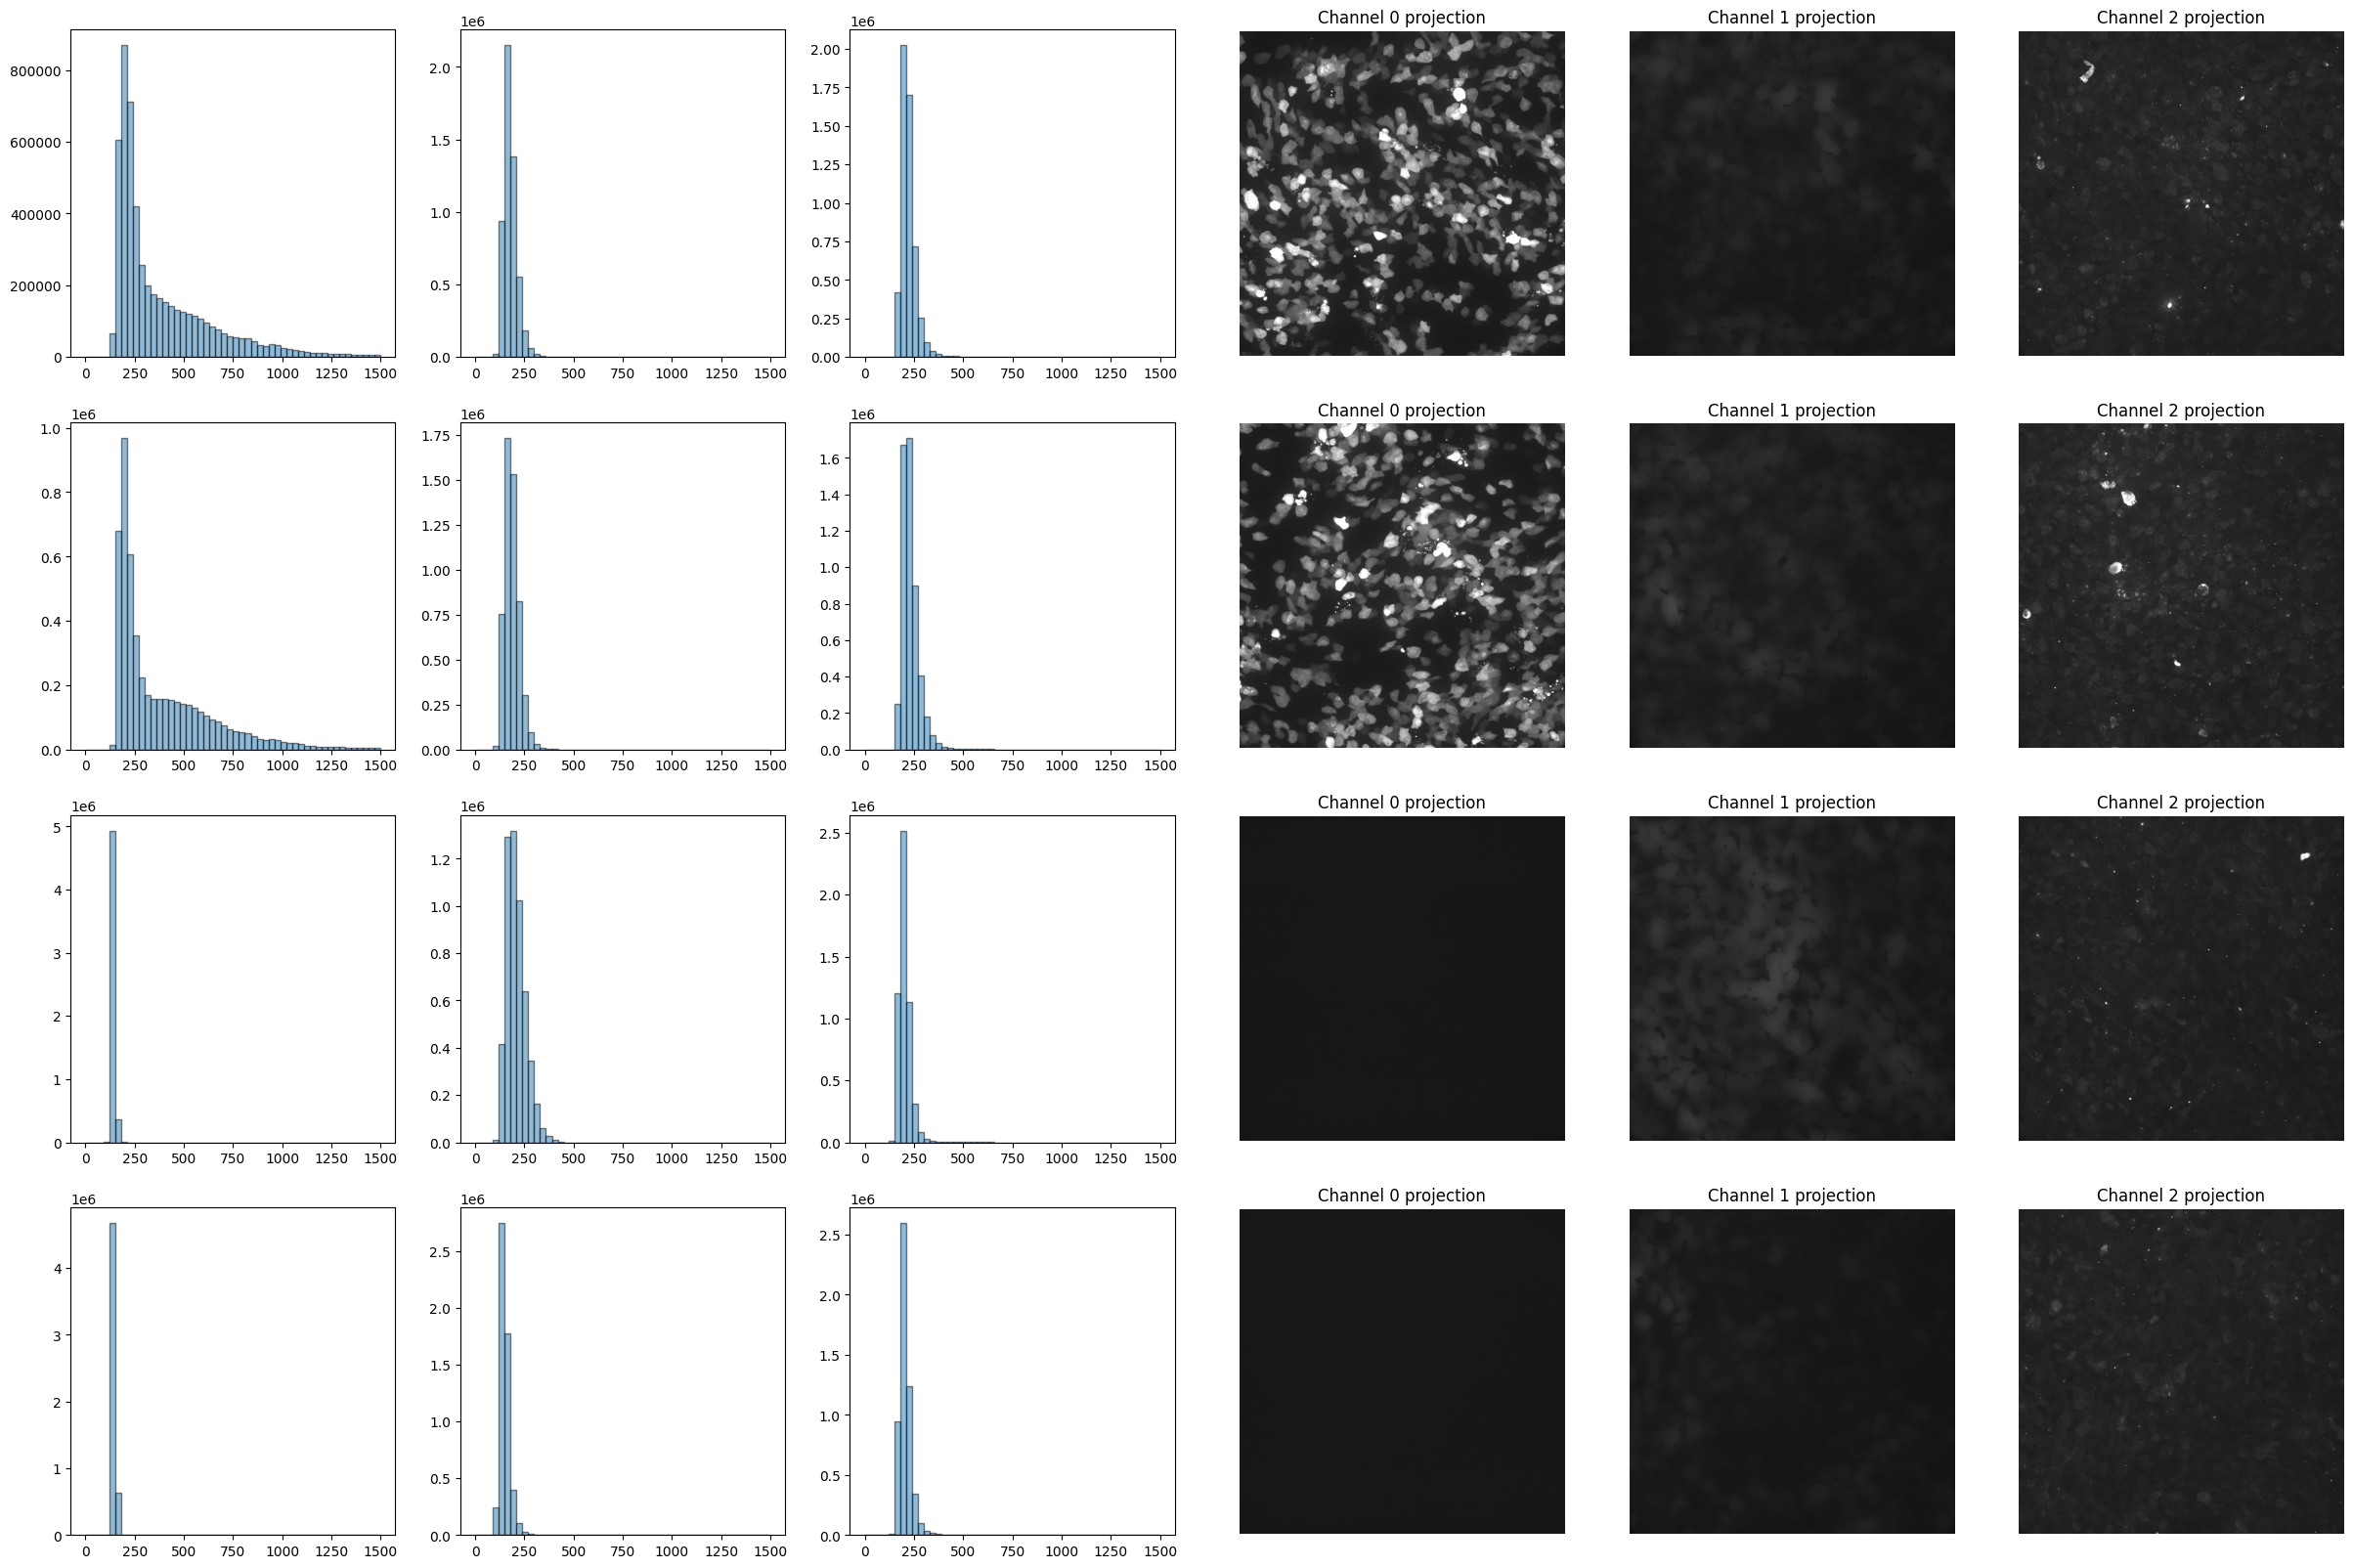

In [16]:
print("Example shape:", ca.projections[0].shape)
projections = [p for p in ca.projections if p is not None]

fig, ax = plt.subplots(len(projections), 2*num_c, figsize=(5*2*num_c, 5*len(projections)))

for i, proj_ex in enumerate(projections):
    if proj_ex is None:
        print(f"Projection for image {i} is None, skipping.")
        continue

    print(f"Image {i} - ranges per channel:", [(proj_ex[c].min(), proj_ex[c].max()) for c in range(proj_ex.shape[0])])

    for c in range(num_c):
        ax[i, c].hist(proj_ex[c].ravel(), bins=50, range=display_range, alpha=0.5, edgecolor='black')
        im_norm = proj_ex[c]
        ax[i, num_c + c].imshow(im_norm, cmap='gray', vmin=display_range[0], vmax=display_range[1])
        ax[i, num_c + c].set_title(f"Channel {c} projection")
        ax[i, num_c + c].axis('off')

In [ ]:
# ca.save(out_path + r"\CellAnalyzer", overwrite=False)

## Segmentation

In [ ]:
# ca.masks = [None] * len(ca.projections) # Initialize masks list to match projections length
# ca.outlines = [None] * len(ca.projections) # Initialize outlines list to match projections length
# ca.samples_df["has_segmentation"] = False # Initialize segmentation tracking in samples_df

In [18]:
masks, flows, styles, imgs_dn, outlines = ca.segment_cells(diameter=75, channels=[3,0], log=False, num_imgs=4, overwrite=False)

Status: 4/4 segmented, 4/4 projected.
Nothing was changed. Use overwrite=True to start a new segmentation round.


In [20]:
ca.create_cells_df(calculate_neighbours=True)

In [21]:
print("Cells DF num rows:", len(ca.cells_df))
display(ca.cells_df.head())
display(ca.cells_df.tail())
display(ca.samples_df)

Cells DF num rows: 1351


,prefix,condition,temp,host,donor,mag,time,date,sample,replicate,sample_id,filename,filepath,num_neighbours
cell_id,,,,,,,,,,,,,,
1,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0
2,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0
3,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0
4,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0
5,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0


,prefix,condition,temp,host,donor,mag,time,date,sample,replicate,sample_id,filename,filepath,num_neighbours
cell_id,,,,,,,,,,,,,,
1347,m,mock,33,Human,D5,40x,48hpi,2025-07-16,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,1
1348,m,mock,33,Human,D5,40x,48hpi,2025-07-16,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0
1349,m,mock,33,Human,D5,40x,48hpi,2025-07-16,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0
1350,m,mock,33,Human,D5,40x,48hpi,2025-07-16,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0
1351,m,mock,33,Human,D5,40x,48hpi,2025-07-16,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,1


,prefix,condition,temp,host,donor,mag,time,date,sample,replicate,sample_id,filename,filepath,has_projection,has_segmentation,num_cells,cell_id_min,cell_id_max
0,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,True,True,330,1,330
1,v,229E,33,Human,D5,40x,48hpi,2025-07-16,002,2,D5_2,v_229E_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,True,True,399,331,729
2,m,mock,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,m_mock_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,True,True,332,730,1061
3,m,mock,33,Human,D5,40x,48hpi,2025-07-16,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,True,True,290,1062,1351


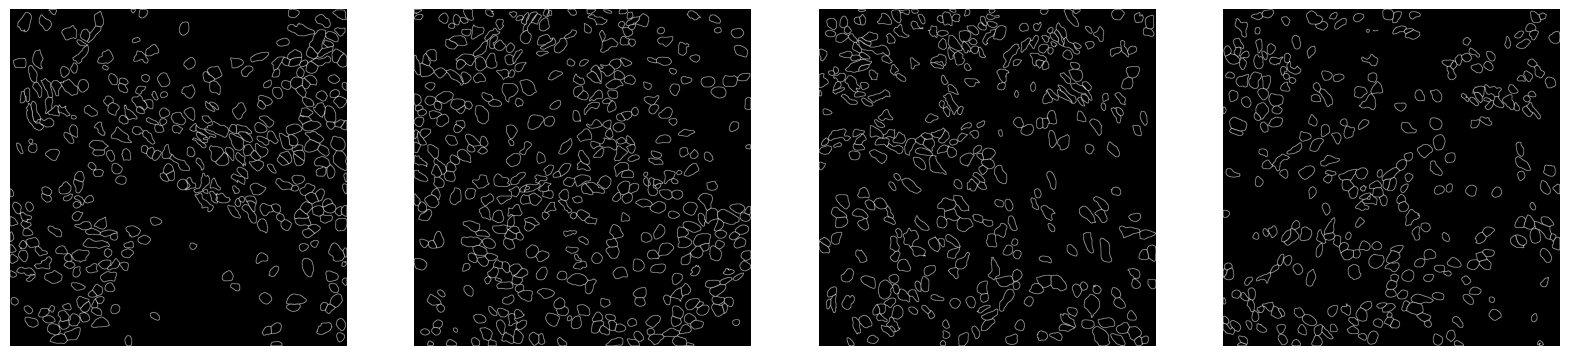

In [22]:
cols = 4
rows = np.ceil(num_imgs / cols).astype(int)
fig, ax = plt.subplots(rows, cols, figsize = (cols * 5, rows * 5))
ax_lin = ax.ravel()

for i in range(num_imgs):
    ax_lin[i].imshow(morphology.dilation(ca.outlines[i], np.ones((3,3))), cmap='gray') # ca.masks[i])
    ax_lin[i].axis("off")
plt.show()

In [68]:
ca.save_segmentation_imgs(background_channels=[3, 2, 1], norm_per_img=False, overwrite=True, folder_name=out_path + r"\Segmentation_Masks")

2/4 outlines saved.
2/4 masks saved.


In [ ]:
# ca.save(out_path + r"\CellAnalyzer", overwrite=True)

## Get the cell signals (means, percentiles etc.)

In [23]:
# cells_df, signal_masks = ca.calculate_cell_signals(channels = {"infection":2, "cilia":4}, mode="mean")
# cells_df, signal_masks = ca.calculate_single_cell_signal(channel_name="goblet", channel_num=1, mode="perc_25")
cells_df, signal_masks = ca.calculate_cell_signals(channels={"goblet": 1, "infection":2, "cilia": 3},
                                                   dilate={"infection": 0, "cilia": -5},
                                                   mode={"goblet": "perc_25"})

No dilation value given for goblet, applying no dilation/erosion for this channel.
No mode value given for infection, applying 'mean' for this channel.
No mode value given for cilia, applying 'mean' for this channel.


c:\Users\roman\miniforge3\envs\ivi-env\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\roman\miniforge3\envs\ivi-env\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [24]:
ca.cells_df.head()

,prefix,condition,temp,host,donor,mag,time,date,sample,replicate,sample_id,filename,filepath,num_neighbours,goblet_signal,goblet_signal_log10,infection_signal,infection_signal_log10,cilia_signal,cilia_signal_log10
cell_id,,,,,,,,,,,,,,,,,,,,
1,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,317.0,2.501059,172.979126,2.237994,222.837901,2.347989
2,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,165.0,2.217484,249.066342,2.396315,244.171630,2.387695
3,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,144.0,2.158362,191.171863,2.281424,240.947605,2.381923
4,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,154.0,2.187521,237.829525,2.376266,238.639175,2.377742
5,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,188.0,2.274158,181.586500,2.259084,233.591606,2.368457


In [25]:
ca.channels_df

,channel_name,projection,signal_dilate,signal_mode
0,goblet,max,0,perc_25
1,infection,min,0,mean
2,cilia,max,-5,mean


In [27]:
# ca.cells_df.groupby('prefix').agg({'num_neighbours':'mean', 'infection_mean_log10':['mean', 'std'], 'goblet_mean_log10':'mean', 'cilia_mean_log10':'mean'})
ca.cells_df.groupby('prefix').agg({'num_neighbours':'mean', 'infection_signal_log10':['mean', 'std'], 'goblet_signal_log10':'mean', 'cilia_signal_log10':'mean'})

num_neighbours infection_signal_log10           goblet_signal_log10  \
                 mean                   mean       std                mean   
prefix                                                                       
m            0.710611               2.262497  0.106765            2.126640   
v            0.825789               2.268947  0.076749            2.467905   

       cilia_signal_log10  
                     mean  
prefix                     
m                2.359385  
v                2.423096

In [28]:
mock_inf_log10 = ca.cells_df[ca.cells_df['prefix']=='m']['infection_signal_log10'].values

# inf_log10_thresh = mock_inf_log10.mean() + 3 * mock_inf_log10.std()
# inf_log10_thresh_low = mock_inf_log10.mean() + 1 * mock_inf_log10.std()

inf_log10_thresh = np.percentile(mock_inf_log10, 99.99)
inf_log10_thresh_low = np.percentile(mock_inf_log10, 95)

threshs = [inf_log10_thresh, inf_log10_thresh_low]
print(f"Inf log10 thresholds: {inf_log10_thresh_low} | {inf_log10_thresh}")

Inf log10 thresholds: 2.4610719143877273 | 2.563632680739206


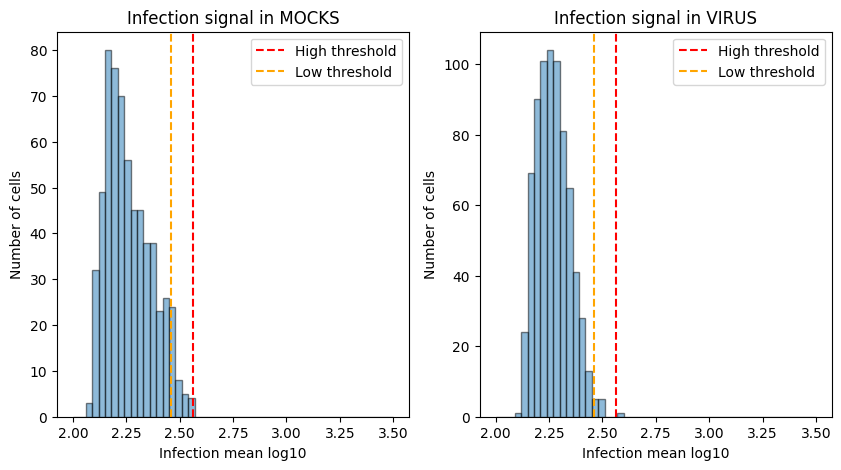

In [29]:
virus_inf_log10 = ca.cells_df[ca.cells_df['prefix']=='v']['infection_signal_log10'].values

fig, ax = plt.subplots(1,2, figsize=(2*5,1*5))

ax[0].hist(mock_inf_log10, bins=50, alpha=0.5, edgecolor='black', range=(2,3.5))
ax[0].set_title('Infection signal in MOCKS')
ax[1].hist(virus_inf_log10, bins=50, alpha=0.5, edgecolor='black', range=(2,3.5))
ax[1].set_title('Infection signal in VIRUS')
for a in ax:
    a.axvline(inf_log10_thresh, color='red', linestyle='--', label='High threshold')
    a.axvline(inf_log10_thresh_low, color='orange', linestyle='--', label='Low threshold')
    a.set_xlabel('Infection mean log10')
    a.set_ylabel('Number of cells')
    a.legend()
plt.show()

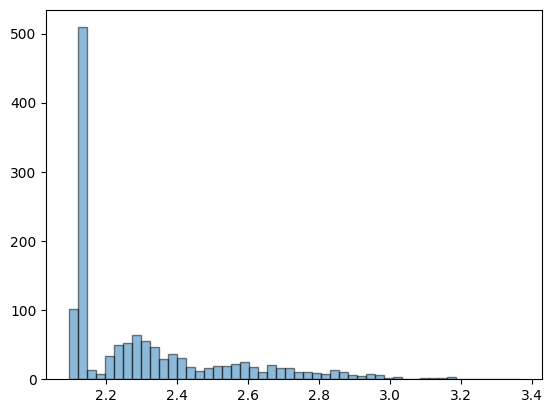

In [54]:
# files = ca.cells_df['filename'].unique()
# num_cols = 4
# num_rows = np.ceil(len(files) / num_cols).astype(int)
# fig, ax = plt.subplots(num_rows, num_cols, figsize=(num_cols*5, num_rows*5))
# all_ax = ax.ravel()
# for i, image in enumerate(files):
#     signal = ca.cells_df[(ca.cells_df['filename'] == image)]['goblet_signal_log10'].values
#     all_ax[i].hist(signal, bins=50, alpha=0.5, edgecolor='black', range=(2,3.5))
#     all_ax[i].set_title('Goblet signal in MOCKS')

plt.hist(ca.cells_df['goblet_signal_log10'].values, bins=50, alpha=0.5, edgecolor='black')

plt.show()

In [55]:
ca.save_signal_masks(folder_name=out_path + r"\Signal_Masks", overwrite=True)

4 masks for signal 'goblet' saved.
4 masks for signal 'infection' saved.
4 masks for signal 'cilia' saved.


In [ ]:
# ca.save(out_path + r"\CellAnalyzer", overwrite=False)

## Bin/threshold

In [30]:
cells_df, bin_masks = ca.bin_cell_signals(signals=["infection", "goblet", "cilia"], use_log=True) #, thresh=None) # thresh=threshs)

Starting binning of signals: ['infection', 'goblet', 'cilia']
Using Otsu's method to find the threshold for infection_signal_log10: 2.279955154590528
Thresholding 'positive' at 2.279955154590528
Using Otsu's method to find the threshold for goblet_signal_log10: 2.443839878060448
Thresholding 'positive' at 2.443839878060448
Using Otsu's method to find the threshold for cilia_signal_log10: 2.640018910477897
Thresholding 'positive' at 2.640018910477897
Finished binning of signals: ['infection', 'goblet', 'cilia']


In [ ]:
# ca.bin_cell_signals("goblet", use_log=True) #, thresh=2.75)

In [ ]:
# ca.bin_cell_signal("cilia", use_log=True, thresh=None)

In [31]:
ca.cells_df.head()

,prefix,condition,temp,host,donor,mag,time,date,sample,replicate,...,num_neighbours,goblet_signal,goblet_signal_log10,infection_signal,infection_signal_log10,cilia_signal,cilia_signal_log10,infection_bin,goblet_bin,cilia_bin
cell_id,,,,,,,,,,,,,,,,,,,,,
1,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,...,0,317.0,2.501059,172.979126,2.237994,222.837901,2.347989,negative,positive,negative
2,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,...,0,165.0,2.217484,249.066342,2.396315,244.171630,2.387695,positive,negative,negative
3,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,...,0,144.0,2.158362,191.171863,2.281424,240.947605,2.381923,positive,negative,negative
4,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,...,0,154.0,2.187521,237.829525,2.376266,238.639175,2.377742,positive,negative,negative
5,v,229E,33,Human,D5,40x,48hpi,2025-07-16,001,1,...,0,188.0,2.274158,181.586500,2.259084,233.591606,2.368457,negative,negative,negative


In [32]:
ca.channels_df

,channel_name,projection,signal_dilate,signal_mode,bin_use_log,bin_threshold_type,bin_threshold(s)
0,goblet,max,0,perc_25,True,otsu,[2.443839878060448]
1,infection,min,0,mean,True,otsu,[2.279955154590528]
2,cilia,max,-5,mean,True,otsu,[2.640018910477897]


In [61]:
for sig in ["infection_signal", "goblet_signal", "cilia_signal"]:
    print(f"Signal: {sig}")
    print(f"MOCKS: {ca.cells_df[ca.cells_df['prefix']=='m'][sig].value_counts()}")
    print(f"VIRUS: {ca.cells_df[ca.cells_df['prefix']=='v'][sig].value_counts()}")
    print()

Signal: infection_signal
MOCKS: infection_signal
178.840108    1
135.575082    1
174.396066    1
125.623990    1
141.136233    1
             ..
174.190021    1
200.557184    1
212.185050    1
255.133176    1
140.955292    1
Name: count, Length: 622, dtype: int64
VIRUS: infection_signal
172.979126    1
287.879080    1
217.409242    1
167.318558    1
173.342747    1
             ..
144.192051    1
199.535067    1
147.190656    1
176.422306    1
147.503982    1
Name: count, Length: 729, dtype: int64

Signal: goblet_signal
MOCKS: goblet_signal
135.00    114
134.00    108
133.00     83
132.00     64
136.00     61
131.00     44
137.00     41
138.00     27
130.00     26
129.00     15
140.00      9
128.00      7
139.00      6
127.00      5
126.00      3
124.00      2
132.75      1
133.25      1
137.25      1
141.00      1
142.00      1
136.50      1
133.75      1
Name: count, dtype: int64
VIRUS: goblet_signal
186.00    9
174.00    9
168.00    9
179.00    9
189.00    9
         ..
458.75    1


In [132]:
ca.save_bin_masks(folder_name=out_path + r"\Bin_Masks", overwrite=True)

4 bin masks for signal 'infection' saved.
4 bin masks for signal 'goblet' saved.
4 bin masks for signal 'cilia' saved.


In [ ]:
ca.save(out_path + r"\CellAnalyzer", overwrite=False)

## Test tiff saving

In [33]:
ca.save_tiff_stacks(stack_dims=["projections", "bins", "outlines"], overwrite=True, folder_name=out_path + r"\Tiff_Stacks")

4 TIFF stacks saved.


In [34]:
ex_tiff = AICSImage(out_path + r"\Tiff_Stacks\v_229E_33_Human_D5_40x_48hpi_20250716_002.nd2_stack.tiff").data

In [35]:
print(ex_tiff.shape)

(1, 1, 7, 2304, 2304)


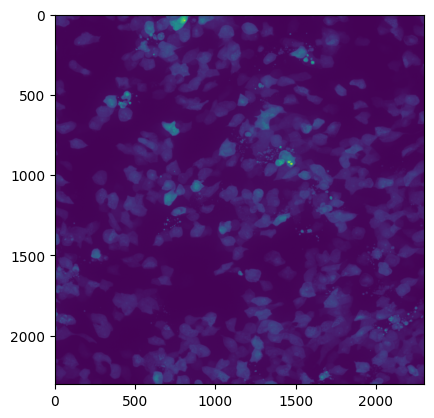

In [36]:
plt.imshow(ex_tiff[0,0,0])

In [37]:
comparison = ca.projections[1][0]

133 5150
133 5150


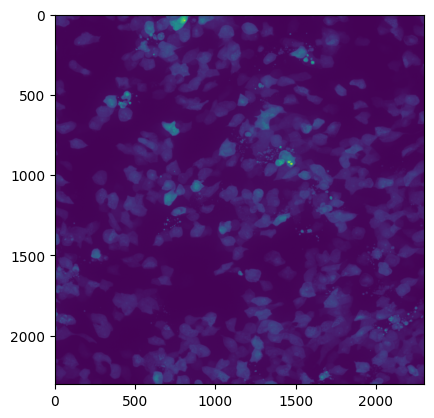

In [39]:
plt.imshow(comparison)
print(ex_tiff[0,0,0].min(), ex_tiff[0,0,0].max())
print(comparison.min(), comparison.max())

## Test regionprops_table

In [40]:
ca.add_region_props() #properties=["max_intensity"])

In [41]:
# display head of all but first 6 columns of cells_df
display(ca.cells_df.iloc[:, 8:].head())
display(ca.cells_df.iloc[:, 8:].tail())

,sample,replicate,sample_id,filename,filepath,num_neighbours,goblet_signal,goblet_signal_log10,infection_signal,infection_signal_log10,...,cilia_signal_log10,infection_bin,goblet_bin,cilia_bin,area,perimeter,eccentricity,orientation,centroid-0,centroid-1
cell_id,,,,,,,,,,,,,,,,,,,,,
1,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,317.0,2.501059,172.979126,2.237994,...,2.347989,negative,positive,negative,3545.0,225.338095,0.628450,-1.507091,28.703244,1937.023977
2,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,165.0,2.217484,249.066342,2.396315,...,2.387695,positive,negative,negative,2879.0,204.024387,0.556687,-0.747575,29.201111,909.438694
3,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,144.0,2.158362,191.171863,2.281424,...,2.381923,positive,negative,negative,1315.0,153.882251,0.690009,1.191361,17.009886,295.627376
4,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,154.0,2.187521,237.829525,2.376266,...,2.377742,positive,negative,negative,569.0,92.183766,0.550434,-1.484234,11.782074,841.652021
5,001,1,D5_1,v_229E_33_Human_D5_40x_48hpi_20250716_001.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,188.0,2.274158,181.586500,2.259084,...,2.368457,negative,negative,negative,4237.0,278.107648,0.760889,1.078913,34.960349,2258.907482


,sample,replicate,sample_id,filename,filepath,num_neighbours,goblet_signal,goblet_signal_log10,infection_signal,infection_signal_log10,...,cilia_signal_log10,infection_bin,goblet_bin,cilia_bin,area,perimeter,eccentricity,orientation,centroid-0,centroid-1
cell_id,,,,,,,,,,,,,,,,,,,,,
1347,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,1,131.0,2.117271,140.414722,2.147413,...,2.319329,negative,negative,negative,2486.0,205.923882,0.816490,0.943453,2261.545857,138.997989
1348,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,131.0,2.117271,146.823869,2.166797,...,2.332063,negative,negative,negative,2078.0,175.195959,0.654297,1.487989,2284.242060,499.823869
1349,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,132.0,2.120574,182.575793,2.261443,...,2.388445,negative,negative,negative,1735.0,176.367532,0.856737,1.302861,2288.084726,1608.945245
1350,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,0,126.0,2.100371,132.786458,2.123154,...,2.322537,negative,negative,negative,960.0,159.681241,0.657667,1.072591,2284.994792,2169.238542
1351,002,2,D5_2,m_mock_33_Human_D5_40x_48hpi_20250716_002.nd2,C:\Users\roman\Documents\Data\vetsuisse_imagin...,1,128.0,2.107210,140.955292,2.149081,...,2.339015,negative,negative,negative,1096.0,148.811183,0.925586,1.529555,2293.610401,128.283759


## Populations

In [171]:
ca.create_cells_df()

In [96]:
# col_name = "inf_cil_gob_(inf-otsu_gob_perc_25_log10_manual_2.75)" # "inf_gob_(inf-perc95-99.99)"
cells_df = ca.create_populations(["infection", "cilia", "goblet"]) # "goblet_perc_25_log10_manual_2.75"], col_name=col_name)

In [160]:
ca.cells_df[["area", "cell_area_px"]].head()

,area,cell_area_px
0,3545.0,3545
1,2879.0,2879
2,1315.0,1315
3,569.0,569
4,4237.0,4237


In [99]:
col_name = "inf_cil_gob_pop" # "inf_gob_(inf-perc95-99.99)"
print("MOCKS:")
mock_non_partials = ca.cells_df[(ca.cells_df['prefix']=='m') & (ca.cells_df['infection_bin']!="partial")][col_name]
mock_non_partials.value_counts()

MOCKS:


inf_cil_gob_pop
inf-neg_cil-neg_gob-pos    7615
inf-neg_cil-pos_gob-pos    4781
inf-neg_cil-neg_gob-neg    4228
inf-neg_cil-pos_gob-neg    2003
Name: count, dtype: int64

In [100]:
print("VIRUS:")
virus_non_partials = ca.cells_df[(ca.cells_df['prefix']=='v') & (ca.cells_df['infection_bin']!="partial")][col_name]
virus_non_partials.value_counts()

VIRUS:


inf_cil_gob_pop
inf-neg_cil-neg_gob-neg    3896
inf-pos_cil-neg_gob-neg    2677
inf-neg_cil-neg_gob-pos    2665
inf-neg_cil-pos_gob-pos    2251
inf-pos_cil-neg_gob-pos    1759
inf-neg_cil-pos_gob-neg    1744
inf-pos_cil-pos_gob-neg    1579
inf-pos_cil-pos_gob-pos    1434
Name: count, dtype: int64

In [130]:
ca.save_population_masks(signals=["cilia", "infection", "goblet"], folder_name=out_path + r"\Population_Masks", overwrite=True)

16 populations saved.
Legend saved.
Folder: C:\Users\roman\Documents\Data\vetsuisse_imaging_data\ALI_examples\Population_Masks\cil_inf_gob_pop


In [ ]:
ca.save(out_path + r"\CellAnalyzer", overwrite=False)

In [131]:
ca.save_population_masks(signals=["cilia", "infection"], folder_name=out_path + r"\Population_Masks", overwrite=True, rgb_channels=(0, 1))
ca.save_population_masks(signals=["infection", "goblet"], folder_name=out_path + r"\Population_Masks", overwrite=True, rgb_channels=(1, 2))
ca.save_population_masks(signals=["cilia", "goblet"], folder_name=out_path + r"\Population_Masks", overwrite=True, rgb_channels=(0, 2))

16 populations saved.
Legend saved.
Folder: C:\Users\roman\Documents\Data\vetsuisse_imaging_data\ALI_examples\Population_Masks\cil_inf_pop
16 populations saved.
Legend saved.
Folder: C:\Users\roman\Documents\Data\vetsuisse_imaging_data\ALI_examples\Population_Masks\inf_gob_pop
16 populations saved.
Legend saved.
Folder: C:\Users\roman\Documents\Data\vetsuisse_imaging_data\ALI_examples\Population_Masks\cil_gob_pop


## Analyze results

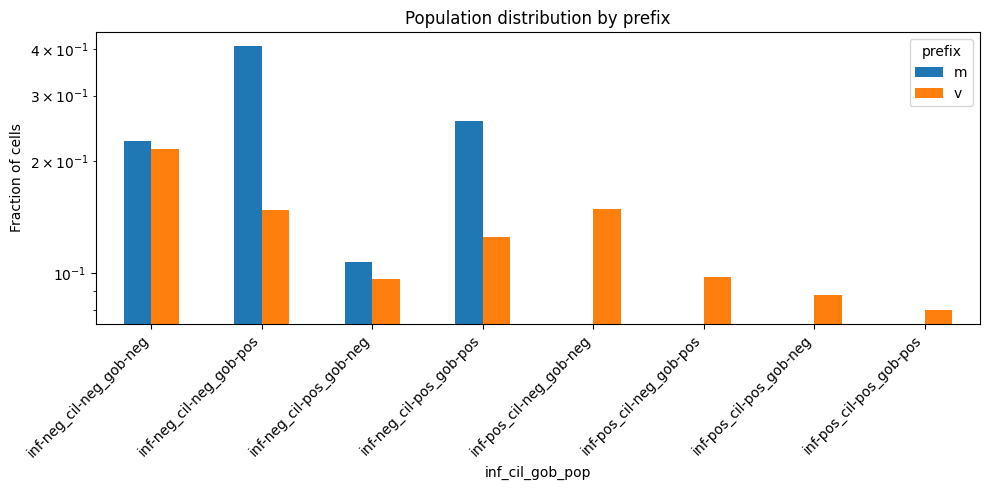

In [104]:
# pop_col = col_name
pop_col = "inf_cil_gob_pop"

# Get cells_df without infection "partial"AICSImage
df = ca.cells_df[ca.cells_df['infection_bin']!="partial"]

# Count occurrences of each population per condition
# counts = df.groupby(["prefix", "inf_cil_gob_pop"]).size().reset_index(name="count")
counts = df.groupby(["prefix", pop_col]).size().reset_index(name="count")

# Optionally normalize to relative frequencies
counts["freq"] = counts.groupby("prefix")["count"].transform(lambda x: x / x.sum())

# Pivot for plotting
pivot = counts.pivot(index=pop_col, columns="prefix", values="freq").fillna(0)

# Plot as grouped bar chart
pivot.plot(kind="bar", figsize=(10,5))
plt.yscale("log")
plt.ylabel("Fraction of cells")
plt.title("Population distribution by prefix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [105]:
second_signal = 'goblet_bin' #'goblet_perc_25_log10_manual_2.75'
signal_title = "goblet" if "goblet" in second_signal else "cilia" if "cilia" in second_signal else second_signal
signal_title

'goblet'

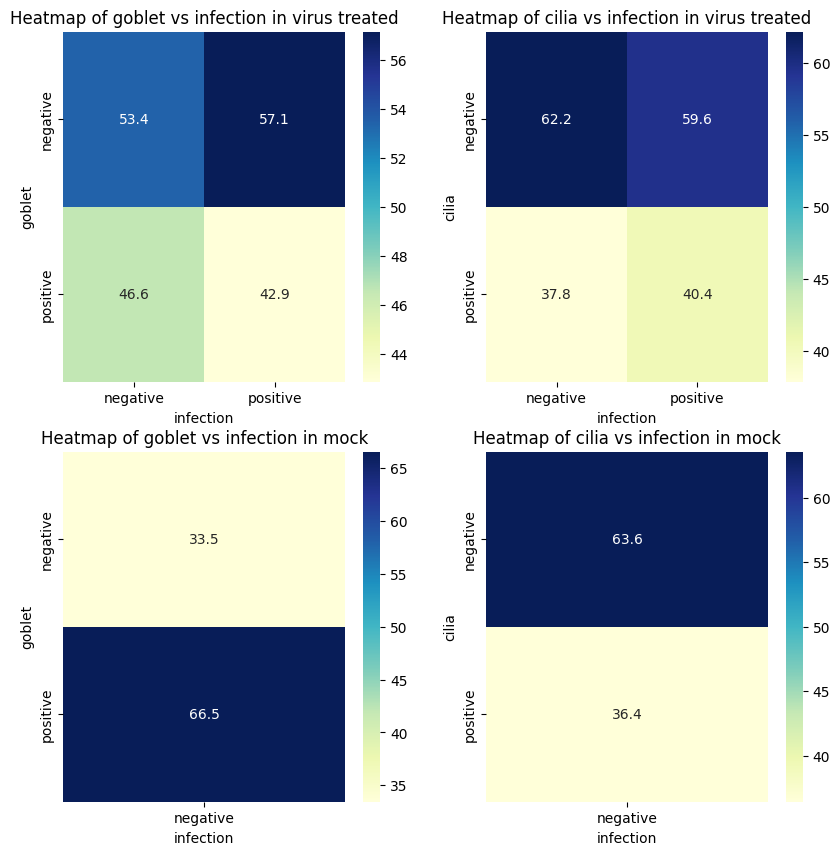

In [108]:
prefixes = ['v', 'm']
second_signals = ['goblet_bin', 'cilia_bin'] #['goblet_perc_25_log10_manual_2.75', 'cilia']
fig, ax = plt.subplots(2,2, figsize=(2*5,2*5))
for i, prefix in enumerate(prefixes):
    for j, second_signal in enumerate(second_signals):
        ax_ = ax[i, j]
        # Plot a heatmap with goblet against infection
        df_subset = ca.cells_df[ca.cells_df['prefix'] == prefix]
        # Make sure to use infected as x axis
        # pivot = pd.crosstab(df_subset[second_signal], df_subset['infection'])
        pivot = pd.crosstab(df_subset[second_signal], 
                    df_subset['infection_bin'], 
                    normalize='columns') * 100
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax_)
        sample_title = {'v':'virus treated', 'm': 'mock'}[prefix]
        signal_title = "goblet" if "goblet" in second_signal else "cilia" if "cilia" in second_signal else second_signal
        ax_.set_title(f"Heatmap of {signal_title} vs infection in {sample_title}")
        ax_.set_xlabel("infection")
        ax_.set_ylabel(signal_title)